In [1]:
import pandas as pd
import numpy as np
from arch import arch_model

df = pd.read_csv('../../data/gold_policy_clean.csv', parse_dates=['date'])

# ── Constants ─────────────────────────────────────────────────────────────────
DUTY_CUT    = pd.Timestamp('2024-07-24')
POLICY_DATE = pd.Timestamp('2026-05-13')

# ── Daily first-differences of premium (low-duty window, primary spec) ────────
gdata = (df[df['date'] >= DUTY_CUT][['date', 'domestic_premium']]
           .dropna()
           .reset_index(drop=True))
gdata['ret'] = gdata['domestic_premium'].diff()
gdata = gdata.dropna().reset_index(drop=True)

pre  = gdata[gdata['date'] <  POLICY_DATE]
post = gdata[gdata['date'] >= POLICY_DATE]

print(f'Pre-hike  : N={len(pre)},  std=₹{pre["ret"].std():,.1f}')
print(f'Post-hike : N={len(post)}, std=₹{post["ret"].std():,.1f}')
print(f'Std ratio (post/pre): {post["ret"].std()/pre["ret"].std():.2f}×')

Pre-hike  : N=359,  std=₹1,686.8
Post-hike : N=31, std=₹2,491.7
Std ratio (post/pre): 1.48×


In [2]:
import warnings; warnings.filterwarnings('ignore')

# ── Fit GARCH(1,1) on full low-duty window ────────────────────────────────────
am  = arch_model(gdata['ret'], mean='Constant', vol='Garch', p=1, q=1, dist='normal')
res = am.fit(disp='off')

print(res.summary().tables[1])

# ── Conditional volatility by regime ─────────────────────────────────────────
cond_vol = res.conditional_volatility   # daily std in ₹

pre_mask  = gdata['date'] <  POLICY_DATE
post_mask = gdata['date'] >= POLICY_DATE

mean_vol_pre  = cond_vol[pre_mask].mean()
mean_vol_post = cond_vol[post_mask].mean()

print(f'\nMean conditional vol  pre-hike : ₹{mean_vol_pre:,.1f}/day')
print(f'Mean conditional vol post-hike : ₹{mean_vol_post:,.1f}/day')
print(f'Ratio (post/pre)               : {mean_vol_post/mean_vol_pre:.2f}×')
print(f'\nPersistence (α+β)              : {res.params["alpha[1]"]+res.params["beta[1]"]:.4f}')

                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu            34.9248     56.731      0.616      0.538 [-76.265,1.461e+02]

Mean conditional vol  pre-hike : ₹1,615.6/day
Mean conditional vol post-hike : ₹2,342.6/day
Ratio (post/pre)               : 1.45×

Persistence (α+β)              : 0.9917


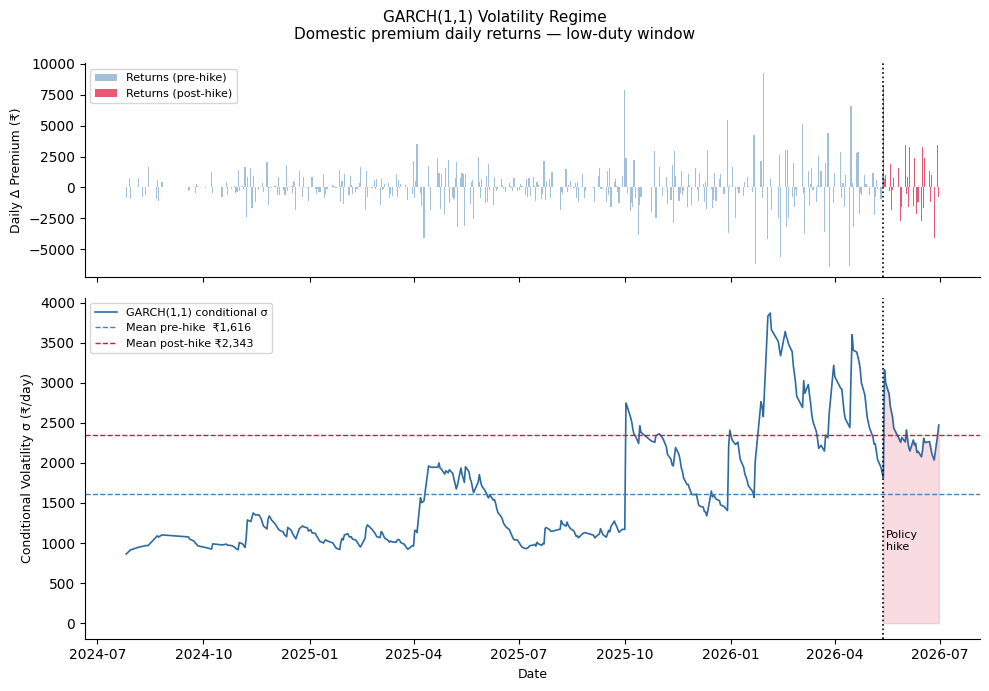

Saved: charts/fig_garch_volatility.png


In [3]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1.6]})

# ── Top panel: premium returns ────────────────────────────────────────────────
ax1.bar(gdata[pre_mask]['date'],  gdata[pre_mask]['ret'],
        color='steelblue', alpha=0.5, width=1, label='Returns (pre-hike)')
ax1.bar(gdata[post_mask]['date'], gdata[post_mask]['ret'],
        color='crimson', alpha=0.7, width=1, label='Returns (post-hike)')
ax1.axvline(POLICY_DATE, color='black', lw=1.2, linestyle=':')
ax1.set_ylabel('Daily Δ Premium (₹)', fontsize=9)
ax1.legend(fontsize=8, loc='upper left')
ax1.spines[['top', 'right']].set_visible(False)

# ── Bottom panel: conditional volatility ─────────────────────────────────────
ax2.plot(gdata['date'], cond_vol, color='#2d6a9f', lw=1.2, label='GARCH(1,1) conditional σ')
ax2.axhline(mean_vol_pre,  color='steelblue', lw=1, linestyle='--',
            label=f'Mean pre-hike  ₹{mean_vol_pre:,.0f}')
ax2.axhline(mean_vol_post, color='crimson',   lw=1, linestyle='--',
            label=f'Mean post-hike ₹{mean_vol_post:,.0f}')
ax2.axvline(POLICY_DATE, color='black', lw=1.2, linestyle=':')
ax2.text(POLICY_DATE + pd.Timedelta(2, 'D'), cond_vol.min() + 50,
         'Policy\nhike', fontsize=8)
ax2.fill_between(gdata[post_mask]['date'], 0, cond_vol[post_mask],
                 alpha=0.15, color='crimson')
ax2.set_ylabel('Conditional Volatility σ (₹/day)', fontsize=9)
ax2.set_xlabel('Date', fontsize=9)
ax2.legend(fontsize=8, loc='upper left')
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle('GARCH(1,1) Volatility Regime\nDomestic premium daily returns — low-duty window',
             fontsize=11)
plt.tight_layout()
plt.savefig('../../charts/fig_garch_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/fig_garch_volatility.png')

In [4]:
from scipy import stats
from statsmodels.stats.diagnostic import het_arch

# ── Formal tests ──────────────────────────────────────────────────────────────
alpha       = res.params['alpha[1]']
beta        = res.params['beta[1]']
persistence = alpha + beta

# Levene: equal variance pre vs post?
lev_stat, lev_p = stats.levene(gdata[pre_mask]['ret'], gdata[post_mask]['ret'])

# Engle ARCH LM test on residuals (confirms GARCH is appropriate)
lm_stat, lm_p, _, _ = het_arch(res.resid, nlags=5)

last_vol  = cond_vol.iloc[-1]
last_date = gdata['date'].iloc[-1].date()

print('=' * 55)
print('GARCH(1,1) Summary')
print('=' * 55)
print(f'omega               : {res.params["omega"]:,.2f}')
print(f'alpha[1] (shock)    : {alpha:.4f}')
print(f'beta[1]  (persist)  : {beta:.4f}')
print(f'Persistence (α+β)   : {persistence:.4f}')
print()
print(f'Mean cond. vol pre-hike : ₹{mean_vol_pre:,.1f}/day')
print(f'Mean cond. vol post-hike: ₹{mean_vol_post:,.1f}/day')
print(f'Ratio (post/pre)        : {mean_vol_post/mean_vol_pre:.2f}×')
print(f'Latest cond. vol ({last_date}): ₹{last_vol:,.1f}/day')
print()
print(f'Levene test (equal var) : F={lev_stat:.3f}, p={lev_p:.4f}')
print(f'ARCH LM test (lag=5)    : LM={lm_stat:.3f}, p={lm_p:.4f}')

GARCH(1,1) Summary
omega               : 62,002.00
alpha[1] (shock)    : 0.1024
beta[1]  (persist)  : 0.8893
Persistence (α+β)   : 0.9917

Mean cond. vol pre-hike : ₹1,615.6/day
Mean cond. vol post-hike: ₹2,342.6/day
Ratio (post/pre)        : 1.45×
Latest cond. vol (2026-06-30): ₹2,471.6/day

Levene test (equal var) : F=11.030, p=0.0010
ARCH LM test (lag=5)    : LM=23.964, p=0.0002
